# Homework 5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Audio
import librosa
import librosa.display
import scipy

In [2]:
data_dir = '/Users/jonathancontreras/Desktop/College Folder/Senior Year/Math485/Unit 3 Voice/voice_clip_selected/'
vc_meta_data = pd.read_csv("voice_clip_meta_data.csv")

# Specification 1: Download Voice Features



In [3]:
#Download voice features from preprocessing in class
features = pd.read_csv('/Users/jonathancontreras/Desktop/College Folder/Senior Year/Math485/Unit 3 Voice/voice_feature_20241022.csv')

# Specification 2: Clustering on the voice clips features, do not include the demographic features of the clips



In [4]:
# define kmeans and elbow method

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import silhouette_score

def find_elbow(df, colnames, clusters_range):
    df_for_cluster = df.loc[:,colnames]
    stscaler = StandardScaler().fit(df_for_cluster)
    normalized_df = stscaler.transform(df_for_cluster)

    inertias = [] # wcss: Within Cluster Sum of Squares
    for k in clusters_range:
        kmeans = KMeans(init='k-means++',n_clusters=k,n_init=100, max_iter=300, random_state=0).fit(normalized_df)
        inertias.append(kmeans.inertia_)
    plt.figure()
    plt.plot(clusters_range,inertias, marker='o')
    plt.title('Elbow method for deciding on k')
    plt.xlabel('Number of clusters: k')
    plt.ylabel('inertia')
    plt.show()
    return

In [5]:
features.columns

Index(['f0_mean', 'f0_std', 'f0_var', 'f0_min', 'f0_max', 'f0_skew',
       'f0_kurtosis', 'zcr_mean', 'zcr_std', 'zcr_var', 'zcr_min', 'zcr_max',
       'zcr_skew', 'zcr_kurtosis', 'mfcc_00', 'mfcc_01', 'mfcc_02', 'mfcc_03',
       'mfcc_04', 'mfcc_05', 'mfcc_06', 'mfcc_07', 'mfcc_08', 'mfcc_09',
       'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15',
       'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'mfcc_20', 'mfcc_21',
       'mfcc_22', 'mfcc_23', 'mfcc_24', 'client_id', 'path', 'sentence_id',
       'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accents',
       'len_in_second', 'sampling_rate', 'array_size'],
      dtype='object')

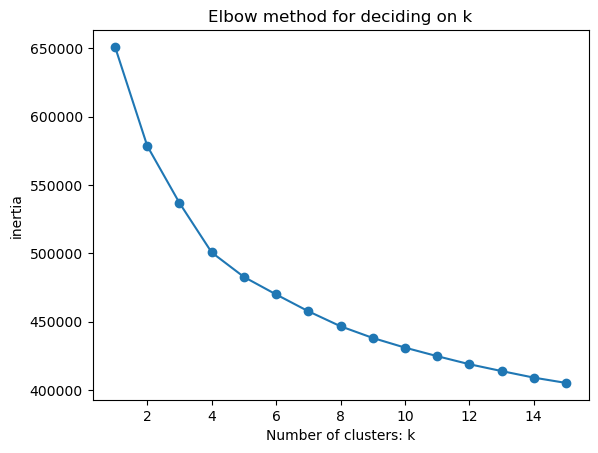

In [6]:
columns = ['f0_mean', 'f0_std', 'f0_var', 'f0_min', 'f0_max', 'f0_skew',
       'f0_kurtosis', 'zcr_mean', 'zcr_std', 'zcr_var', 'zcr_min', 'zcr_max',
       'zcr_skew', 'zcr_kurtosis', 'mfcc_00', 'mfcc_01', 'mfcc_02', 'mfcc_03',
       'mfcc_04', 'mfcc_05', 'mfcc_06', 'mfcc_07', 'mfcc_08', 'mfcc_09',
       'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15',
       'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'mfcc_20', 'mfcc_21',
       'mfcc_22', 'mfcc_23', 'mfcc_24', 'client_id', 'path', 'sentence_id',
       'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accents',
       'len_in_second', 'sampling_rate', 'array_size']
# drop demographic features
feature_columns = ['f0_mean', 'f0_std', 'f0_var', 'f0_min', 'f0_max', 'f0_skew',
       'f0_kurtosis', 'zcr_mean', 'zcr_std', 'zcr_var', 'zcr_min', 'zcr_max',
       'zcr_skew', 'zcr_kurtosis', 'mfcc_00', 'mfcc_01', 'mfcc_02', 'mfcc_03',
       'mfcc_04', 'mfcc_05', 'mfcc_06', 'mfcc_07', 'mfcc_08', 'mfcc_09',
       'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15',
       'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'mfcc_20', 'mfcc_21',
       'mfcc_22', 'mfcc_23', 'mfcc_24']

#drop missing values in f0_kurtosis column
features.dropna(subset = ['f0_kurtosis'],axis=0, inplace=True)

clusters_range = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
find_elbow(df=features, colnames=feature_columns,clusters_range=clusters_range)

We decide on k = 4 as most suitable for k-means clustering given the elbow of the graph.

# Specification 3: Using subsets of the voice features for clustering

In [7]:
# Subset 1: Only f0
colnames_f0 = ['f0_mean', 'f0_std', 'f0_var', 'f0_min', 'f0_max', 'f0_skew',
       'f0_kurtosis']
# Subset 2: Only ZCR
colnames_zcr = ['zcr_mean', 'zcr_std', 'zcr_var', 'zcr_min', 'zcr_max',
       'zcr_skew', 'zcr_kurtosis']
# Subset 3: Only mfcc
colnames_mfcc = ['mfcc_00', 'mfcc_01', 'mfcc_02', 'mfcc_03',
       'mfcc_04', 'mfcc_05', 'mfcc_06', 'mfcc_07', 'mfcc_08', 'mfcc_09',
       'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15',
       'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'mfcc_20', 'mfcc_21',
       'mfcc_22', 'mfcc_23', 'mfcc_24']
# Subset 4: exclude mfcc
colnames_not_mfcc = ['f0_mean', 'f0_std', 'f0_var', 'f0_min', 'f0_max', 'f0_skew',
       'f0_kurtosis', 'zcr_mean', 'zcr_std', 'zcr_var', 'zcr_min', 'zcr_max',
       'zcr_skew', 'zcr_kurtosis']

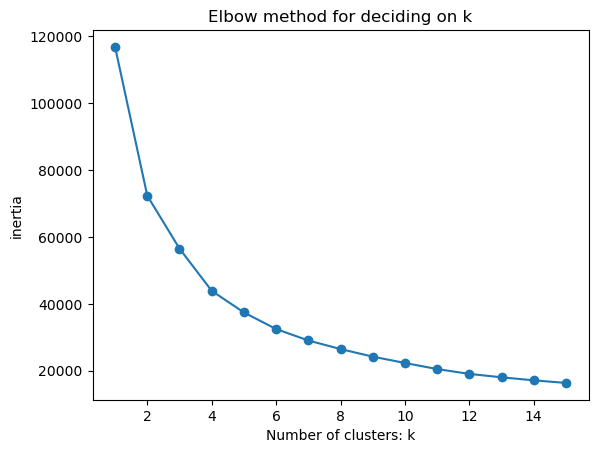

In [8]:
# Subset 1: Only f0
colnames_f0 = ['f0_mean', 'f0_std', 'f0_var', 'f0_min', 'f0_max', 'f0_skew',
       'f0_kurtosis']
clusters_range = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
find_elbow(df=features, colnames=colnames_f0,clusters_range=clusters_range)

It appears k = 2 or perhaps k = 4 are the most suitible in this case

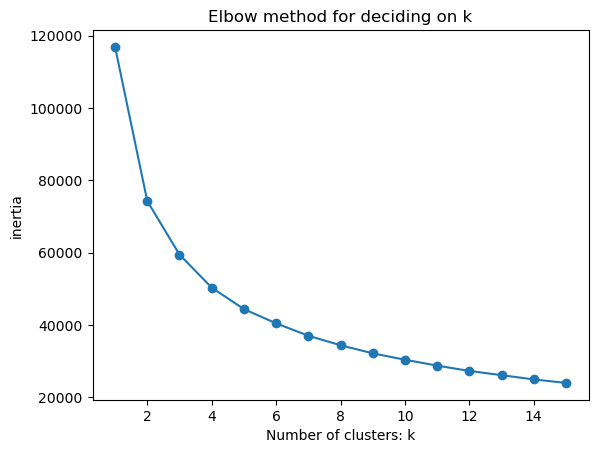

In [9]:
# Subset 2: Only ZCR
colnames_zcr = ['zcr_mean', 'zcr_std', 'zcr_var', 'zcr_min', 'zcr_max',
       'zcr_skew', 'zcr_kurtosis']
find_elbow(df=features, colnames=colnames_zcr,clusters_range=clusters_range)

It appears k = 2 is the most suitible in this case (A case may be made for k=3 as well).

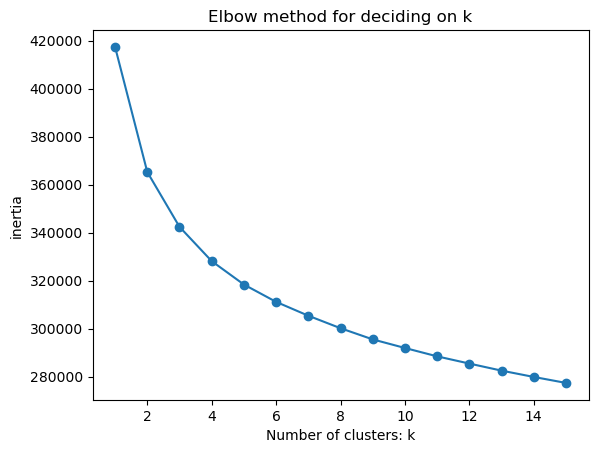

In [10]:
# Subset 3: Only mfcc
colnames_mfcc = ['mfcc_00', 'mfcc_01', 'mfcc_02', 'mfcc_03',
       'mfcc_04', 'mfcc_05', 'mfcc_06', 'mfcc_07', 'mfcc_08', 'mfcc_09',
       'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15',
       'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'mfcc_20', 'mfcc_21',
       'mfcc_22', 'mfcc_23', 'mfcc_24']
find_elbow(df=features, colnames=colnames_mfcc,clusters_range=clusters_range)

It appears k = 2 is also the most suitible in this case (There is also an argument for k=3).

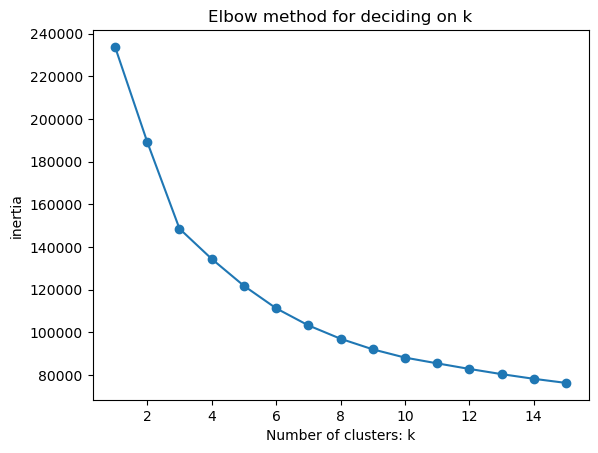

In [11]:
# Subset 4: exclude mfcc
colnames_not_mfcc = ['f0_mean', 'f0_std', 'f0_var', 'f0_min', 'f0_max', 'f0_skew',
       'f0_kurtosis', 'zcr_mean', 'zcr_std', 'zcr_var', 'zcr_min', 'zcr_max',
       'zcr_skew', 'zcr_kurtosis']
find_elbow(df=features, colnames=colnames_not_mfcc,clusters_range=clusters_range)

It appears k = 3 is also the most suitible in this case

# Exploring Differences of Subsets

In [125]:
def run_kmeans(df, colnames, k):
    df_for_cluster = df.loc[:,colnames]
    stscaler = StandardScaler().fit(df_for_cluster)
    normalized_df = stscaler.transform(df_for_cluster)

    kmeans = KMeans(init='k-means++',n_clusters=k,n_init=100, max_iter=300, random_state=0).fit(normalized_df)
    df['cluster'] = kmeans.labels_
    return df

In [126]:
k = 4
subset1 = run_kmeans(features, colnames_f0, 4)

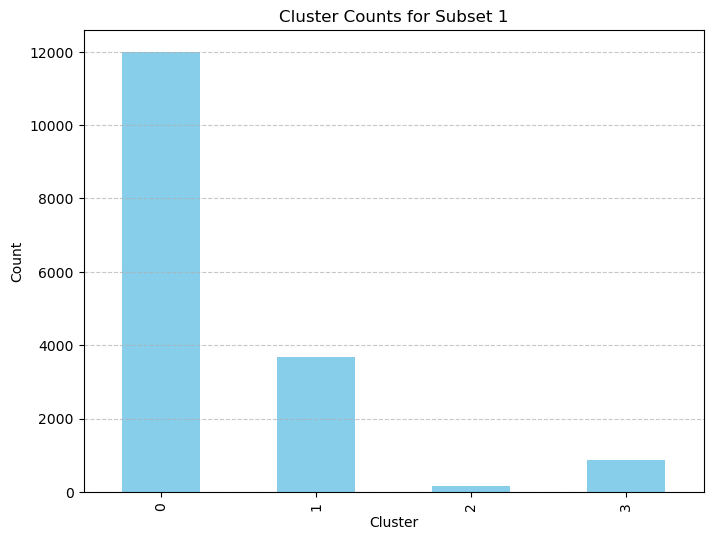

In [127]:
import matplotlib.pyplot as plt

# plot histogram of cluster counts for subset1
plt.figure(figsize=(8, 6))
subset1['cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Cluster Counts for Subset 1')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


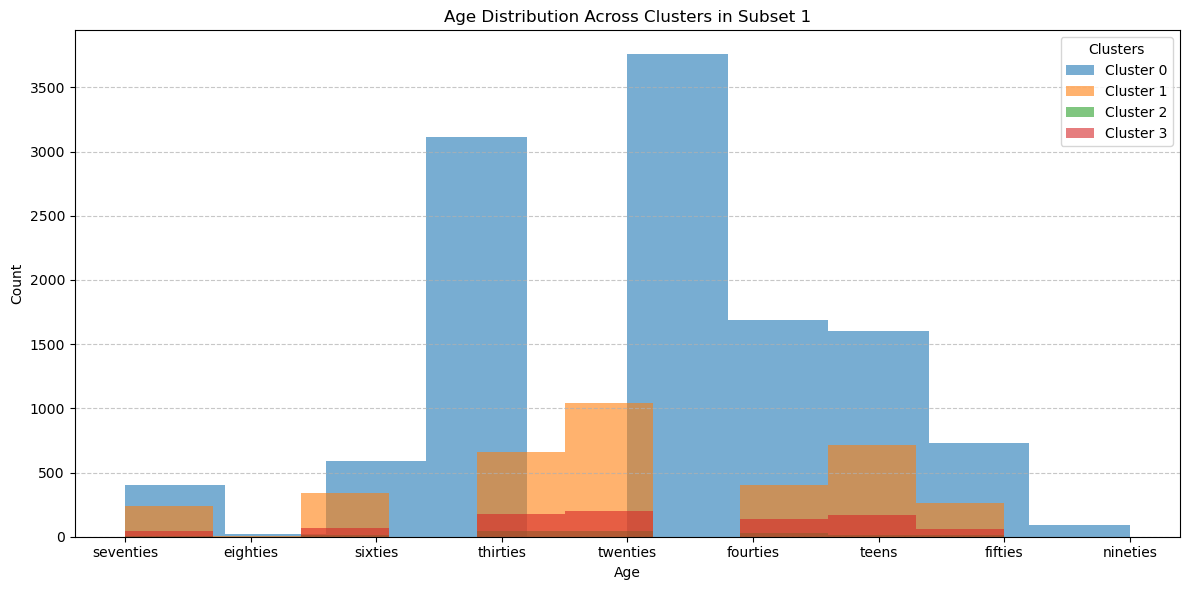

In [128]:
num_clusters = 4
plt.figure(figsize=(12, 6))
for cluster in range(num_clusters):
    cluster_data = subset1[subset1['cluster'] == cluster]['age']  # Filter by cluster
    plt.hist(cluster_data, bins=10, alpha=0.6, label=f'Cluster {cluster}')

# Add plot details
plt.title('Age Distribution Across Clusters in Subset 1')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Clusters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [129]:
k = 2
subset2= run_kmeans(features, colnames_zcr, 2)

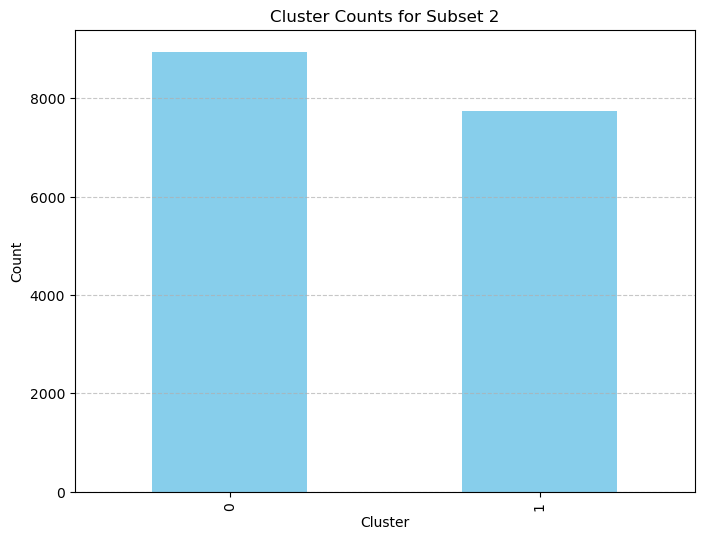

In [130]:
# plot histogram of cluster counts for subset2
plt.figure(figsize=(8, 6))
subset2['cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Cluster Counts for Subset 2')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

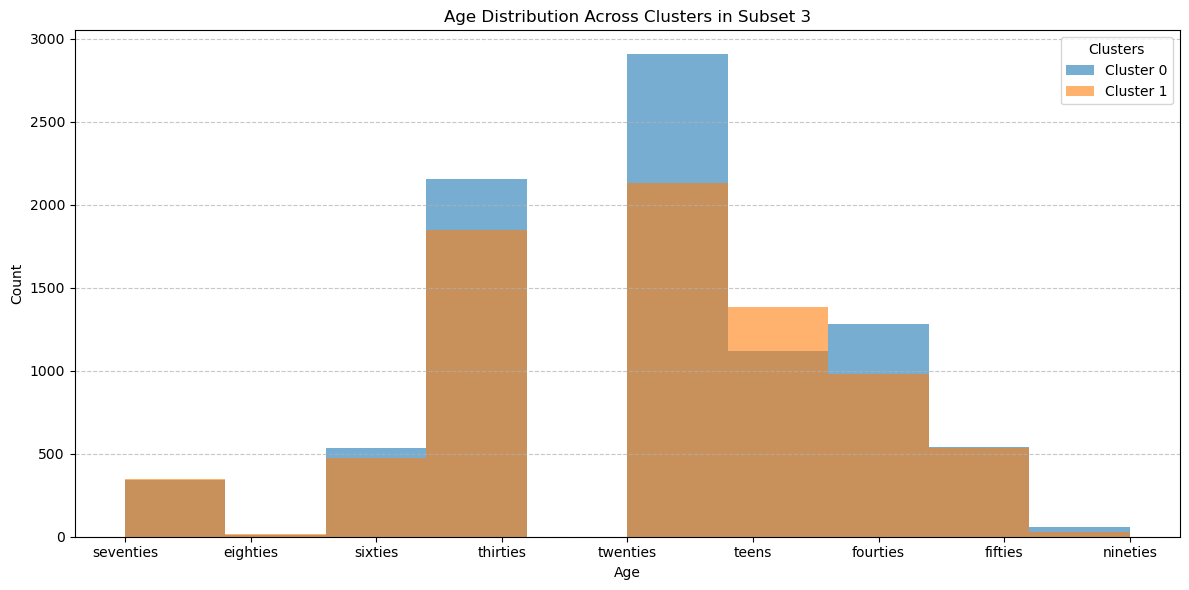

In [131]:
num_clusters = 2
plt.figure(figsize=(12, 6))
for cluster in range(num_clusters):
    cluster_data = subset3[subset3['cluster'] == cluster]['age']  # Filter by cluster
    plt.hist(cluster_data, bins=10, alpha=0.6, label=f'Cluster {cluster}')

# Add plot details
plt.title('Age Distribution Across Clusters in Subset 3')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Clusters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [132]:
subset3 = run_kmeans(features, colnames_mfcc, 2)

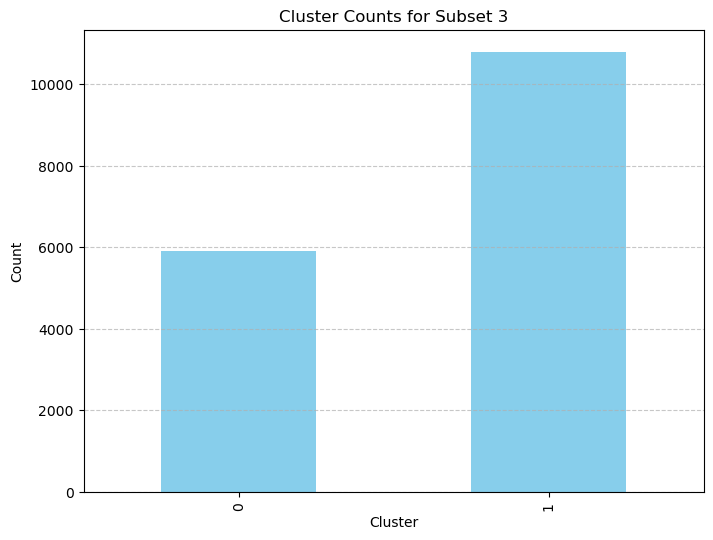

In [133]:
# plot histogram of cluster counts for subset3
plt.figure(figsize=(8, 6))
subset3['cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Cluster Counts for Subset 3')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

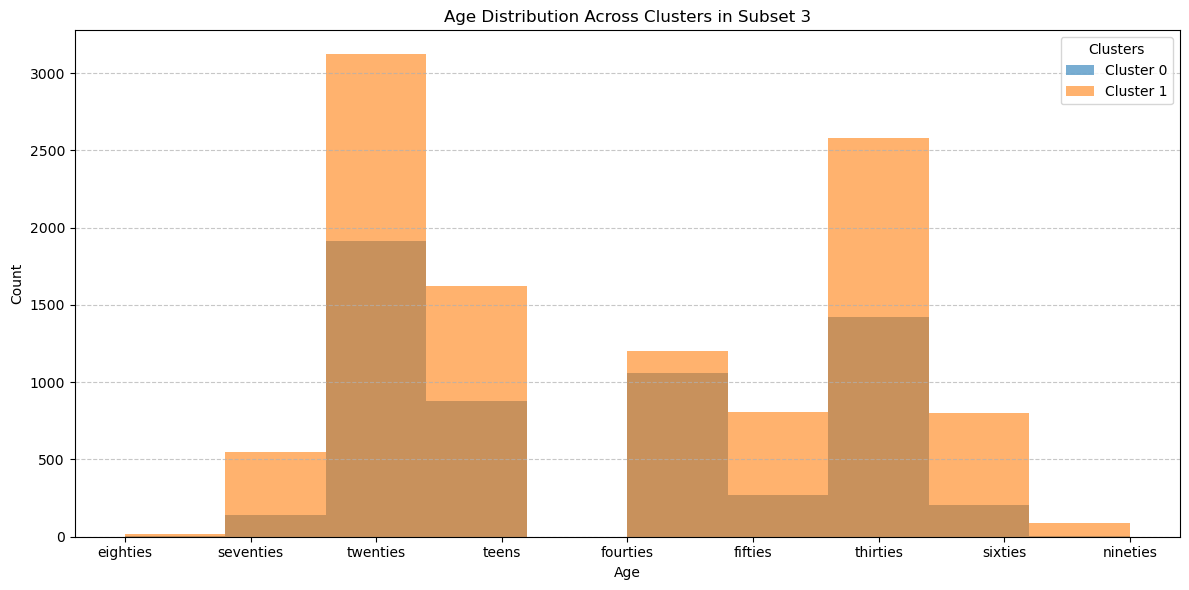

In [134]:
num_clusters = 2
plt.figure(figsize=(12, 6))
for cluster in range(num_clusters):
    cluster_data = subset3[subset3['cluster'] == cluster]['age']  # Filter by cluster
    plt.hist(cluster_data, bins=10, alpha=0.6, label=f'Cluster {cluster}')

# Add plot details
plt.title('Age Distribution Across Clusters in Subset 3')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Clusters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [135]:
k = 3
subset4 = run_kmeans(features, colnames_not_mfcc, 3)

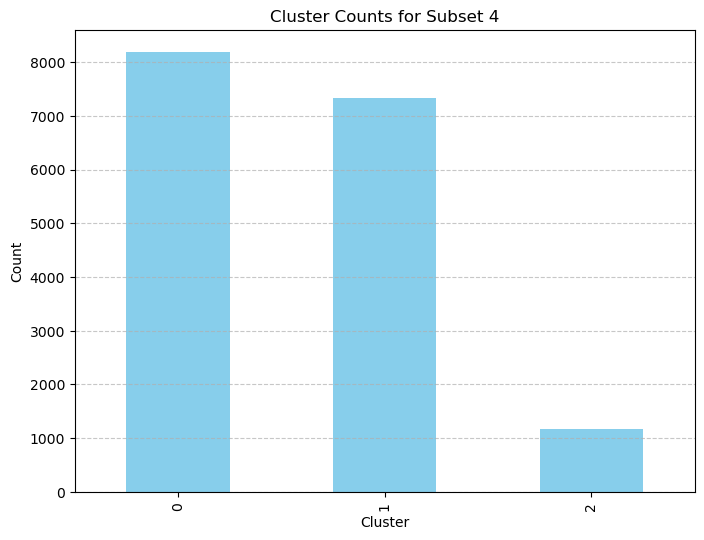

In [136]:
# plot histogram of cluster counts for subset4
plt.figure(figsize=(8, 6))
subset4['cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Cluster Counts for Subset 4')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

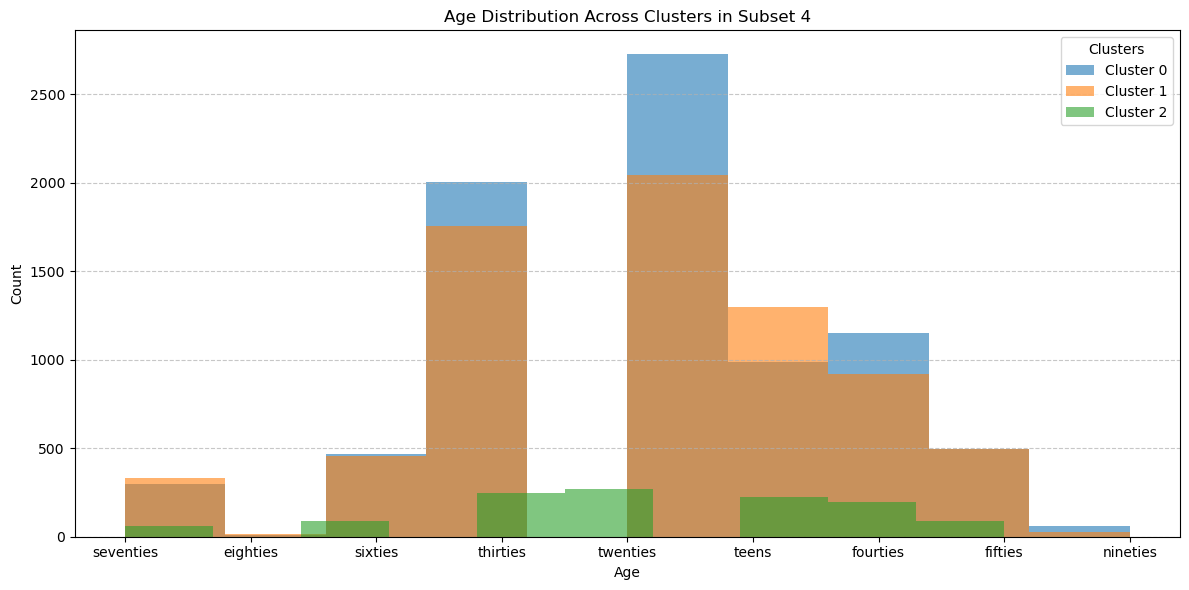

In [137]:
num_clusters = 3
plt.figure(figsize=(12, 6))
for cluster in range(num_clusters):
    cluster_data = subset4[subset4['cluster'] == cluster]['age']  # Filter by cluster
    plt.hist(cluster_data, bins=10, alpha=0.6, label=f'Cluster {cluster}')

# Add plot details
plt.title('Age Distribution Across Clusters in Subset 4')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Clusters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [87]:
subset1.cluster.value_counts()

cluster
0    11998
1     3668
3      856
2      172
Name: count, dtype: int64

We use age as a feature to examen how Kmeans clusters the data using our subsets as the chosen features to cluster. We can see that the k = 2 cluster methods cover similar ground across each cluster, they are relatively similar in size. 

However, for  k = 4 cluster group, there is one cluster that dominates the age feature whereas the other clusters are much more minor. 

For the k = 3 cluster group, it is similar to k = 2, except the third cluster covers a small group of age categories.